### 0. Imports

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### 1. Baseline Detection Performance on PPE

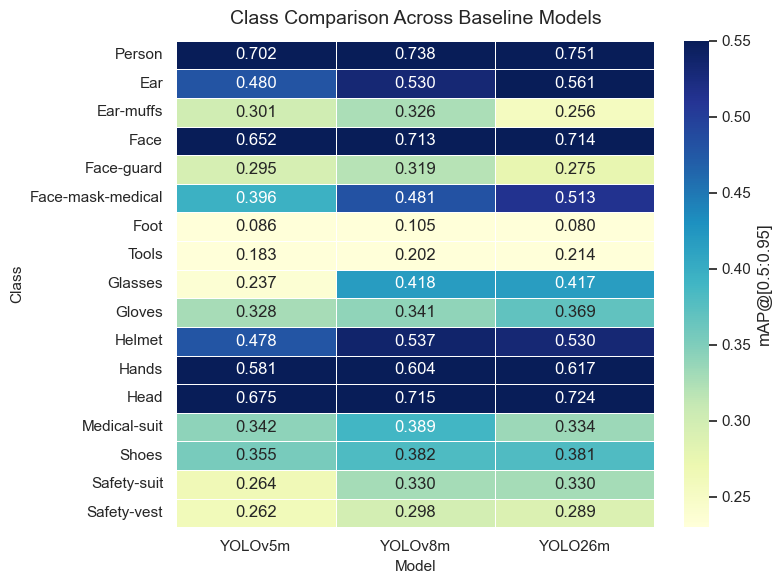

In [55]:
data = {
    "YOLOv5m": [0.702, 0.480, 0.301, 0.652, 0.295, 0.396, 0.0863, 0.183, 0.237, 0.328, 0.478, 0.581, 0.675, 0.342, 0.355, 0.264, 0.262],
    "YOLOv8m": [0.738, 0.530, 0.326, 0.713, 0.319, 0.481, 0.105, 0.202, 0.418, 0.341, 0.537, 0.604, 0.715, 0.389, 0.382, 0.330, 0.298],
    "YOLO26m": [0.751, 0.561, 0.256, 0.714, 0.275, 0.513, 0.0797, 0.214, 0.417, 0.369, 0.530, 0.617, 0.724, 0.334, 0.381, 0.330, 0.289],
}

classes = [
    "Person", "Ear", "Ear-muffs", "Face", "Face-guard", "Face-mask-medical", "Foot", "Tools", "Glasses", "Gloves",
    "Helmet", "Hands", "Head", "Medical-suit", "Shoes", "Safety-suit", "Safety-vest"
]

df = pd.DataFrame(data, index=classes)

plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

ax = sns.heatmap(
    df,
    annot=True,              # show values
    fmt=".3f",
    cmap="YlGnBu",          # perceptually uniform
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "mAP@[0.5:0.95]"},
    vmin=0.23, vmax=0.55     # consistent scale across models
)

ax.set_title("Class Comparison Across Baseline Models", fontsize=14, pad=12)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Class", fontsize=11)

plt.tight_layout()
plt.show()

### 2. Robustness to Visual Perturbations

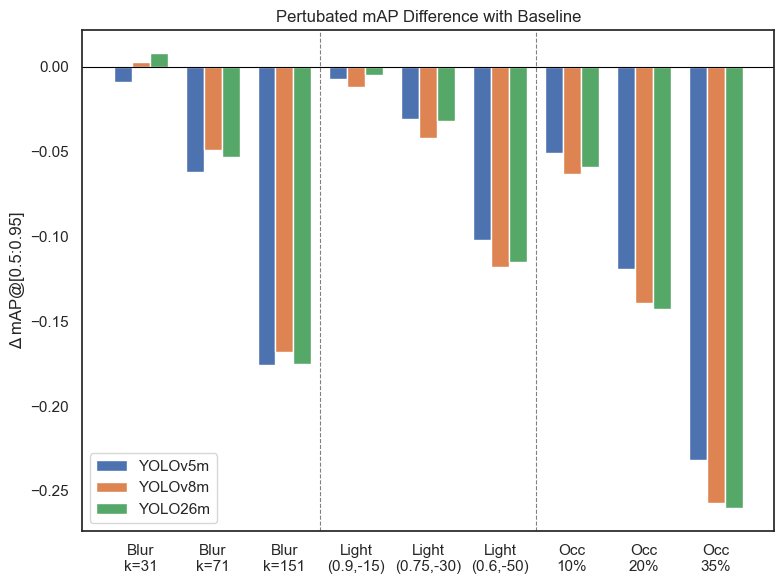

In [56]:
conditions = [
    "Blur\nk=31", "Blur\nk=71", "Blur\nk=151",
    "Light\n(0.9,-15)", "Light\n(0.75,-30)", "Light\n(0.6,-50)",
    "Occ\n10%", "Occ\n20%", "Occ\n35%"
]

# Delta mAP values
yolov5m = [-0.009, -0.062, -0.176, -0.007, -0.031, -0.102, -0.051, -0.119, -0.232]
yolov8m = [ 0.003, -0.049, -0.168, -0.012, -0.042, -0.118, -0.063, -0.139, -0.257]
yolo26m = [ 0.008, -0.053, -0.175, -0.005, -0.032, -0.115, -0.059, -0.143, -0.260]

# X positions
x = np.arange(len(conditions))
width = 0.25

# Plot
plt.figure(figsize=(8,6))
plt.bar(x - width, yolov5m, width, label="YOLOv5m")
plt.bar(x,         yolov8m, width, label="YOLOv8m")
plt.bar(x + width, yolo26m, width, label="YOLO26m")

# Formatting
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(2.5, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(5.5, color="gray", linestyle="--", linewidth=0.8)
plt.xticks(x, conditions, rotation=0)
plt.ylabel("Δ mAP@[0.5:0.95]")
plt.title("Pertubated mAP Difference with Baseline")
plt.legend()
plt.tight_layout()

plt.show()

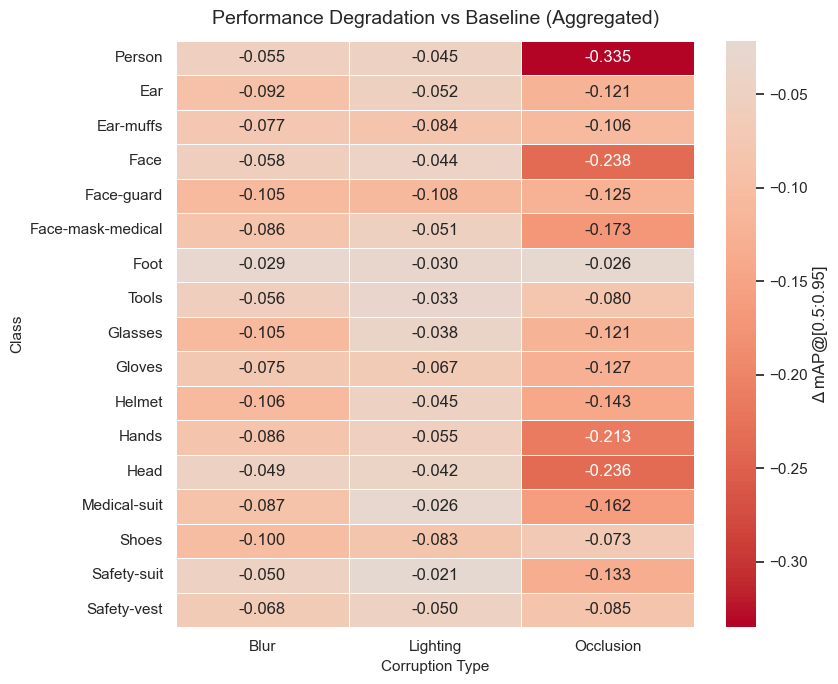

In [57]:
data = {
    "Blur": [
        -0.0546, -0.0920, -0.0771, -0.0579, -0.1049, -0.0859,
        -0.0290, -0.0557, -0.1054, -0.0754, -0.1057, -0.0862,
        -0.0491, -0.0872, -0.1004, -0.0498, -0.0676
    ],
    "Lighting": [
        -0.0450, -0.0516, -0.0842, -0.0444, -0.1077, -0.0511,
        -0.0303, -0.0328, -0.0383, -0.0668, -0.0446, -0.0549,
        -0.0419, -0.0263, -0.0834, -0.0213, -0.0496
    ],
    "Occlusion": [
        -0.3350, -0.1213, -0.1062, -0.2376, -0.1253, -0.1731,
        -0.0261, -0.0804, -0.1207, -0.1267, -0.1431, -0.2130,
        -0.2360, -0.1621, -0.0734, -0.1332, -0.0848
    ]
}

classes = [
    "Person", "Ear", "Ear-muffs", "Face", "Face-guard",
    "Face-mask-medical", "Foot", "Tools", "Glasses", "Gloves",
    "Helmet", "Hands", "Head", "Medical-suit", "Shoes",
    "Safety-suit", "Safety-vest"
]

df = pd.DataFrame(data, index=classes)

# Plot
plt.figure(figsize=(8.5, 7))
sns.set_theme(style="white")

ax = sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm_r",        # strong degradation = darker red
    center=0,                 # zero-centered (important for deltas)
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Δ mAP@[0.5:0.95]"}
)

ax.set_title("Performance Degradation vs Baseline (Aggregated)", fontsize=14, pad=12)
ax.set_xlabel("Corruption Type", fontsize=11)
ax.set_ylabel("Class", fontsize=11)

plt.tight_layout()
plt.show()

### 3. Class Imbalance & Focal Loss Effects

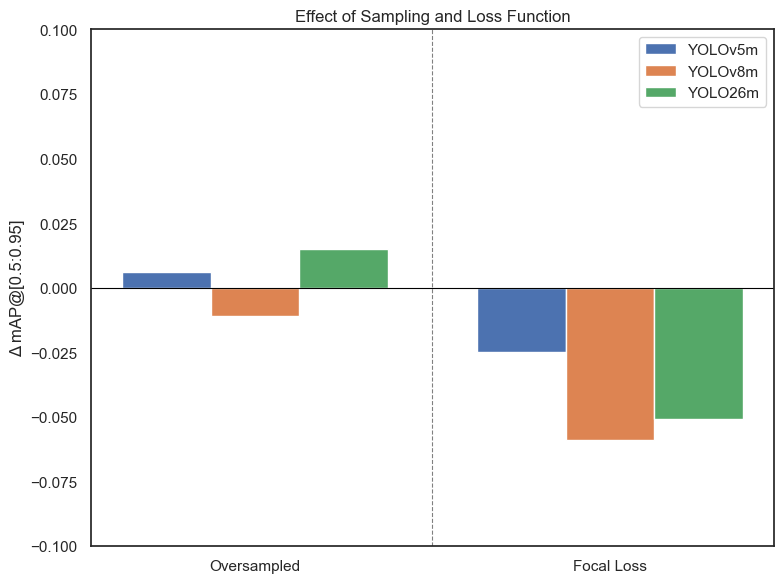

In [58]:
conditions = ["Oversampled", "Focal Loss"]

# Delta mAP values
yolov5m = [0.006, -0.025]
yolov8m = [-0.011, -0.059]
yolo26m = [0.015, -0.051]

# X positions
x = np.arange(len(conditions))
width = 0.25

# Plot
plt.figure(figsize=(8,6))
plt.bar(x - width, yolov5m, width, label="YOLOv5m")
plt.bar(x,         yolov8m, width, label="YOLOv8m")
plt.bar(x + width, yolo26m, width, label="YOLO26m")

# Formatting
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
plt.xticks(x, conditions, rotation=0)
plt.ylabel("Δ mAP@[0.5:0.95]")
plt.title("Effect of Sampling and Loss Function")
plt.legend()

plt.ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()

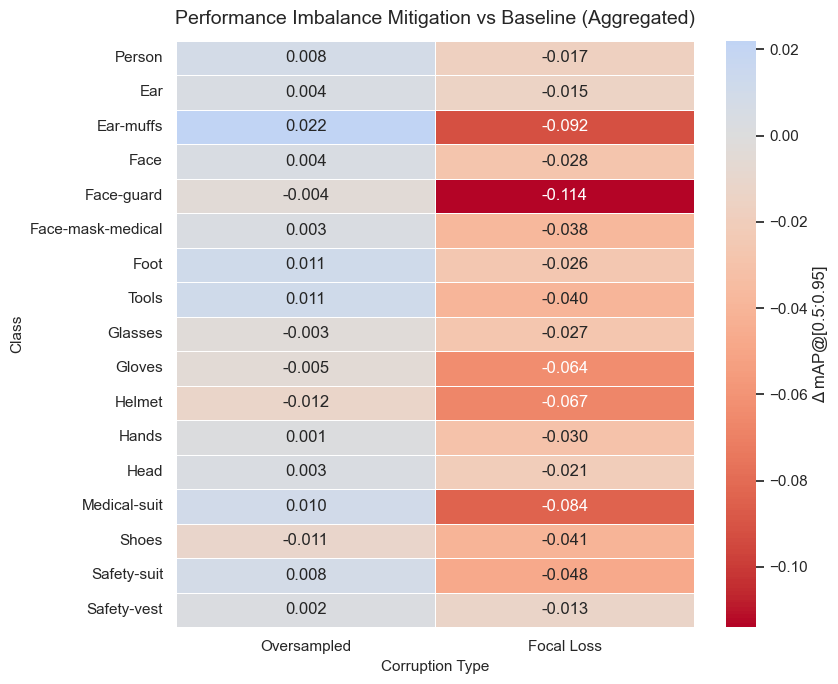

In [59]:
data = {
    "Oversampled": [
        0.008, 0.004, 0.022, 0.004, -0.004, 0.003,
        0.011, 0.011, -0.003, -0.005, -0.012, 0.001,
        0.003, 0.010, -0.011, 0.008, 0.002
    ],
    "Focal Loss": [
        -0.017, -0.015, -0.092, -0.028, -0.114, -0.038, 
        -0.026, -0.040, -0.027, -0.064, -0.067, -0.030, 
        -0.021, -0.084, -0.041, -0.048, -0.013
    ]
}

classes = [
    "Person", "Ear", "Ear-muffs", "Face", "Face-guard",
    "Face-mask-medical", "Foot", "Tools", "Glasses", "Gloves",
    "Helmet", "Hands", "Head", "Medical-suit", "Shoes",
    "Safety-suit", "Safety-vest"
]

df = pd.DataFrame(data, index=classes)

# Plot
plt.figure(figsize=(8.5, 7))
sns.set_theme(style="white")

ax = sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm_r",        # strong degradation = darker red
    center=0,                 # zero-centered (important for deltas)
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Δ mAP@[0.5:0.95]"}
)

ax.set_title("Performance Imbalance Mitigation vs Baseline (Aggregated)", fontsize=14, pad=12)
ax.set_xlabel("Corruption Type", fontsize=11)
ax.set_ylabel("Class", fontsize=11)

plt.tight_layout()
plt.show()